✅ Dataset downloaded!
✅ Data ready | Train: (125973, 41) | Test: (22544, 41)
   Train → Normal: 67343 | Attack: 58630
   Test  → Normal: 9711  | Attack: 12833


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1, 82)          │         3,444 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 82)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        28,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,973 (132.71 KB)

 Trainable params: 33,973 (132.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9858 - loss: 0.0386 - val_accuracy: 0.9881 - val_loss: 0.0298
Epoch 2/500
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9906 - loss: 0.0248 - val_accuracy: 0.9912 - val_loss: 0.0202
Epoch 3/500
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9913 - loss: 0.0222 - val_accuracy: 0.9946 - val_loss: 0.0166
Epoch 4/500
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9928 - loss: 0.0190 - val_accuracy: 0.9919 - val_loss: 0.0193
Epoch 5/500
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9933 - loss: 0.0175 - val_accuracy: 0.9949 - val_loss: 0.0156
Epoch 6/500
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9939 - loss: 0.0168 - val_accuracy: 0.9925 - val_loss: 0.0189
Epoch 7/500
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9942 - loss: 0.0156 - val_accuracy: 0.9956 - val_loss: 0.0136
Epoch 8/500
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9945 -

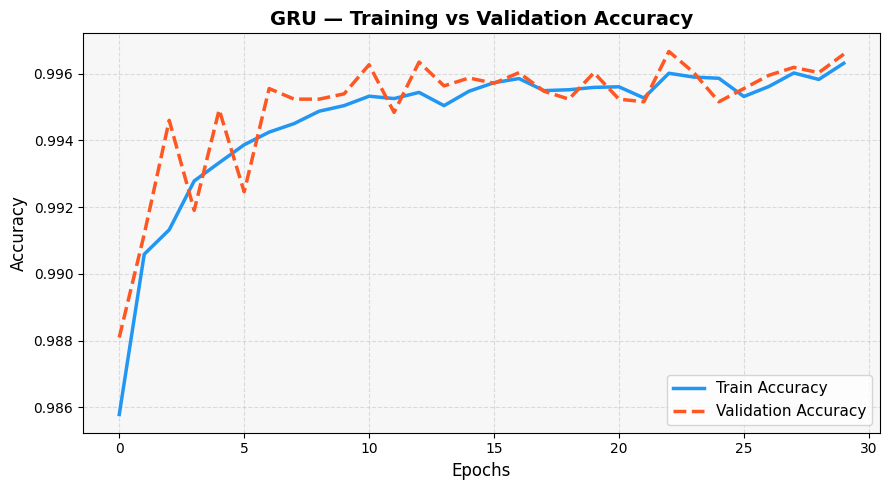

✅ Plot 1 saved


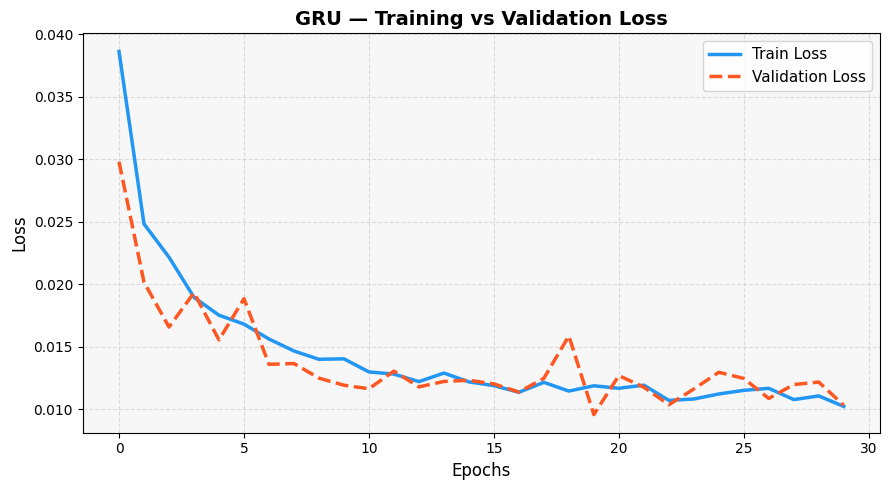

✅ Plot 2 saved


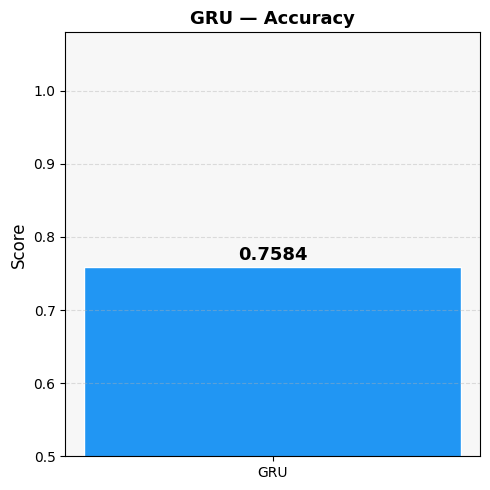

✅ Plot 3 saved


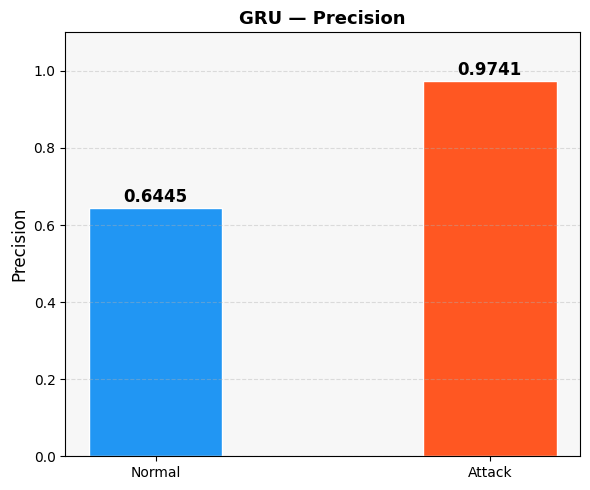

✅ Plot 4 saved


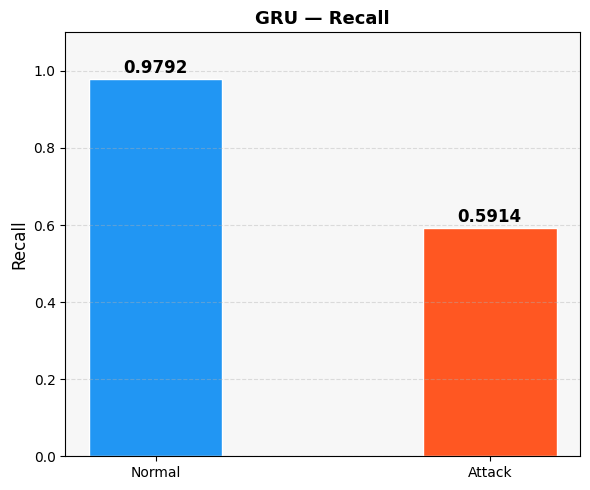

✅ Plot 5 saved


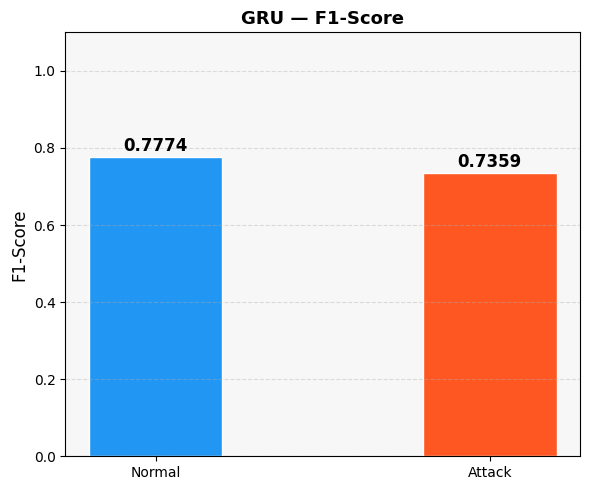

✅ Plot 6 saved


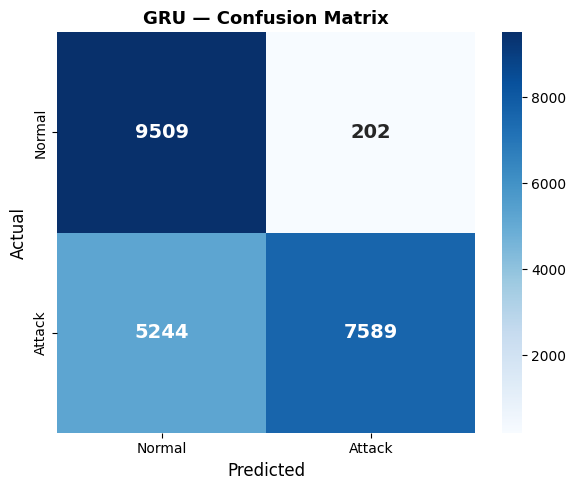

✅ Plot 7 saved


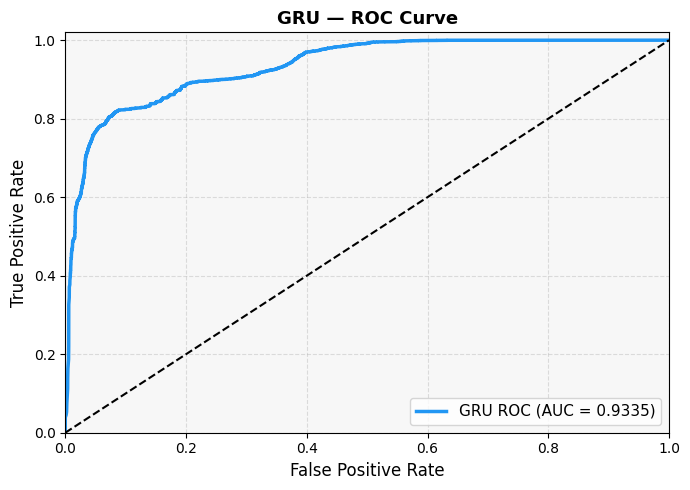

✅ Plot 8 saved

✅✅ ALL GRU PLOTS SAVED! ✅✅


In [2]:
# ================================================================
#  STEP 1: INSTALL & IMPORTS
# ================================================================
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             precision_recall_fscore_support,
                             roc_curve, auc)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Reshape, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ================================================================
#  STEP 2: DOWNLOAD DATASET
# ================================================================
!wget -q "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt" -O KDDTrain.txt
!wget -q "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt" -O KDDTest.txt
print("✅ Dataset downloaded!")

# ================================================================
#  STEP 3: LOAD & PREPROCESS
# ================================================================
cols = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

train_df = pd.read_csv('KDDTrain.txt', names=cols)
test_df  = pd.read_csv('KDDTest.txt',  names=cols)

# Binary labels
train_df['label'] = (train_df['label'] != 'normal').astype(int)
test_df['label']  = (test_df['label']  != 'normal').astype(int)

# Drop difficulty
train_df.drop(columns=['difficulty'], inplace=True)
test_df.drop(columns=['difficulty'],  inplace=True)

# Encode categoricals
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[col], test_df[col]]))
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

X_train = train_df.drop(columns=['label']).values.astype(np.float32)
y_train = train_df['label'].values
X_test  = test_df.drop(columns=['label']).values.astype(np.float32)
y_test  = test_df['label'].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"✅ Data ready | Train: {X_train.shape} | Test: {X_test.shape}")
print(f"   Train → Normal: {(y_train==0).sum()} | Attack: {(y_train==1).sum()}")
print(f"   Test  → Normal: {(y_test==0).sum()}  | Attack: {(y_test==1).sum()}")

# ================================================================
#  STEP 4: BUILD & TRAIN GRU MODEL
# ================================================================
n_features  = X_train.shape[1]
X_train_gru = X_train.reshape(-1, 1, n_features)
X_test_gru  = X_test.reshape(-1, 1, n_features)

model = Sequential([
    Input(shape=(1, n_features)),
    Dense(n_features * 2, activation='relu'),
    Reshape((1, n_features * 2)),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(optimizer=Adam(0.005),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=10,
                   restore_best_weights=True)

history = model.fit(
    X_train_gru, y_train,
    epochs=500,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)
print("✅ GRU Training complete!")

# ================================================================
#  STEP 5: EVALUATE
# ================================================================
y_pred_prob = model.predict(X_test_gru).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"\n{'='*45}")
print(f"  GRU MODEL RESULTS")
print(f"{'='*45}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"{'='*45}")
print(classification_report(y_test, y_pred,
      target_names=['Normal','Attack']))

prec_cls, rec_cls, f1_cls, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=[0,1])
classes = ['Normal', 'Attack']

# ================================================================
#  STEP 6: ALL PLOTS
# ================================================================

# ── PLOT 1: Training Accuracy Curve ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history['accuracy'],     color='#2196F3', linewidth=2.5, label='Train Accuracy')
ax.plot(history.history['val_accuracy'], color='#FF5722', linewidth=2.5, linestyle='--', label='Validation Accuracy')
ax.set_title('GRU — Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.4, linestyle='--')
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('GRU_01_Accuracy_Curve.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved")

# ── PLOT 2: Training Loss Curve ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history['loss'],     color='#2196F3', linewidth=2.5, label='Train Loss')
ax.plot(history.history['val_loss'], color='#FF5722', linewidth=2.5, linestyle='--', label='Validation Loss')
ax.set_title('GRU — Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.4, linestyle='--')
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('GRU_02_Loss_Curve.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved")

# ── PLOT 3: Accuracy Bar ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(['GRU'], [acc], color='#2196F3', width=0.35, edgecolor='white')
ax.text(0, acc+0.005, f'{acc:.4f}', ha='center', va='bottom',
        fontsize=13, fontweight='bold')
ax.set_title('GRU — Accuracy', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.5, 1.08)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('GRU_03_Accuracy.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved")

# ── PLOT 4: Precision Bar ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, prec_cls, color=['#2196F3','#FF5722'],
              width=0.4, edgecolor='white')
for bar, v in zip(bars, prec_cls):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_title('GRU — Precision', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('GRU_04_Precision.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Plot 4 saved")

# ── PLOT 5: Recall Bar ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, rec_cls, color=['#2196F3','#FF5722'],
              width=0.4, edgecolor='white')
for bar, v in zip(bars, rec_cls):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_title('GRU — Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Recall', fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('GRU_05_Recall.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Plot 5 saved")

# ── PLOT 6: F1-Score Bar ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, f1_cls, color=['#2196F3','#FF5722'],
              width=0.4, edgecolor='white')
for bar, v in zip(bars, f1_cls):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_title('GRU — F1-Score', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('GRU_06_F1Score.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Plot 6 saved")

# ── PLOT 7: Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'],
            annot_kws={"size":14, "weight":"bold"})
ax.set_title('GRU — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('GRU_07_Confusion_Matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Plot 7 saved")

# ── PLOT 8: ROC Curve ────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#2196F3', lw=2.5,
        label=f'GRU ROC (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1.5)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('GRU — ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.4, linestyle='--')
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('GRU_08_ROC_Curve.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Plot 8 saved")

print("\n✅✅ ALL GRU PLOTS SAVED! ✅✅")